<a href="https://colab.research.google.com/github/sayed02-debug/big_five_personality/blob/main/BigFive_Personality_BERT_FineTuning_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/behaviour_dataset/personality_dataset_10000.csv'
df = pd.read_csv(path)

df.head()

,cv_text,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,I am sensitive to criticism and tend to worry ...,1,0,1,0,0
1,I am sensitive to criticism and tend to worry ...,0,0,1,1,0
2,I prefer to work alone and tend to avoid socia...,0,1,0,1,0
3,I enjoy collaborating with others and feel ene...,0,0,0,0,0
4,I enjoy collaborating with others and feel ene...,0,1,0,0,1


In [ ]:
!pip install transformers datasets torch accelerate -q

import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, hamming_loss, classification_report

print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [ ]:
import torch
print("GPU Available:", torch.cuda.is_available())
!nvidia-smi

GPU Available: True
Mon Mar  2 07:53:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

In [ ]:
from transformers import BertTokenizer
from datasets import Dataset
from sklearn.model_selection import train_test_split

trait_cols = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']

df['clean_cv_text'] = df['cv_text'].astype(str).str.lower().str.replace(r'[^a-z\s]', '', regex=True).str.strip()

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df[['clean_cv_text'] + trait_cols].rename(columns={'clean_cv_text': 'text'}))
test_dataset = Dataset.from_pandas(test_df[['clean_cv_text'] + trait_cols].rename(columns={'clean_cv_text': 'text'}))

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Combine labels into one column
def make_labels(examples):
    labels = [[examples[trait][i] for trait in trait_cols] for i in range(len(examples['text']))]
    examples['labels'] = labels
    return examples

train_tokenized = train_tokenized.map(make_labels, batched=True, remove_columns=trait_cols)
test_tokenized = test_tokenized.map(make_labels, batched=True, remove_columns=trait_cols)

train_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print("Tokenized & labels ready! Train size:", len(train_tokenized))

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized & labels ready! Train size: 8000


In [ ]:
from transformers import BertForSequenceClassification, TrainingArguments
import torch
from sklearn.metrics import f1_score, hamming_loss

# Load BERT model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=5,
    problem_type="multi_label_classification"
)

# Define metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()
    return {
        'hamming_loss': hamming_loss(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro', zero_division=0),
        'micro_f1': f1_score(labels, preds, average='micro', zero_division=0)
    }

# Define training args
training_args = TrainingArguments(
    output_dir='./bert_bigfive_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=True,
)

print("Model, metrics, and training_args ready!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model, metrics, and training_args ready!


In [ ]:
from transformers import Trainer
import torch.nn as nn

class MultilabelTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.BCEWithLogitsLoss()
        loss = loss_fct(logits, labels.float())
        return (loss, outputs) if return_outputs else loss

trainer = MultilabelTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

print("Trainer ready! Now run trainer.train()")

Trainer ready! Now run trainer.train()


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Hamming Loss,Macro F1,Micro F1,Runtime,Samples Per Second,Steps Per Second
1,0.697147,0.695286,0.500300,0.532886,0.614947,3.899300,512.909000,32.057000
2,0.696216,0.694205,0.499100,0.223283,0.360702,3.889200,514.243000,32.140000
3,0.693725,0.693517,0.502200,0.531617,0.574407,3.924800,509.579000,31.849000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1500, training_loss=0.6956959431966145, metrics={'train_runtime': 239.2701, 'train_samples_per_second': 100.305, 'train_steps_per_second': 6.269, 'total_flos': 1578708854784000.0, 'train_loss': 0.6956959431966145, 'epoch': 3.0})

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
predictions = trainer.predict(test_tokenized)
logits = predictions.predictions
preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()

# Labels extract
labels = np.array(test_tokenized['labels'])  # shape: (num_samples, 5)

print("Predictions shape:", preds.shape)
print("Labels shape:", labels.shape)
print("\nClassification Report:\n")
print(classification_report(labels, preds, target_names=trait_cols, digits=3))

Predictions shape: (2000, 5)
Labels shape: (2000, 5)

Classification Report:

                   precision    recall  f1-score   support

         openness      0.501     1.000     0.668      1002
conscientiousness      0.000     0.000     0.000       998
     extraversion      0.501     1.000     0.668      1003
    agreeableness      0.495     1.000     0.663       991
      neuroticism      0.499     1.000     0.666       999

        micro avg      0.499     0.800     0.615      4993
        macro avg      0.400     0.800     0.533      4993
     weighted avg      0.400     0.800     0.533      4993
      samples avg      0.499     0.770     0.583      4993



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


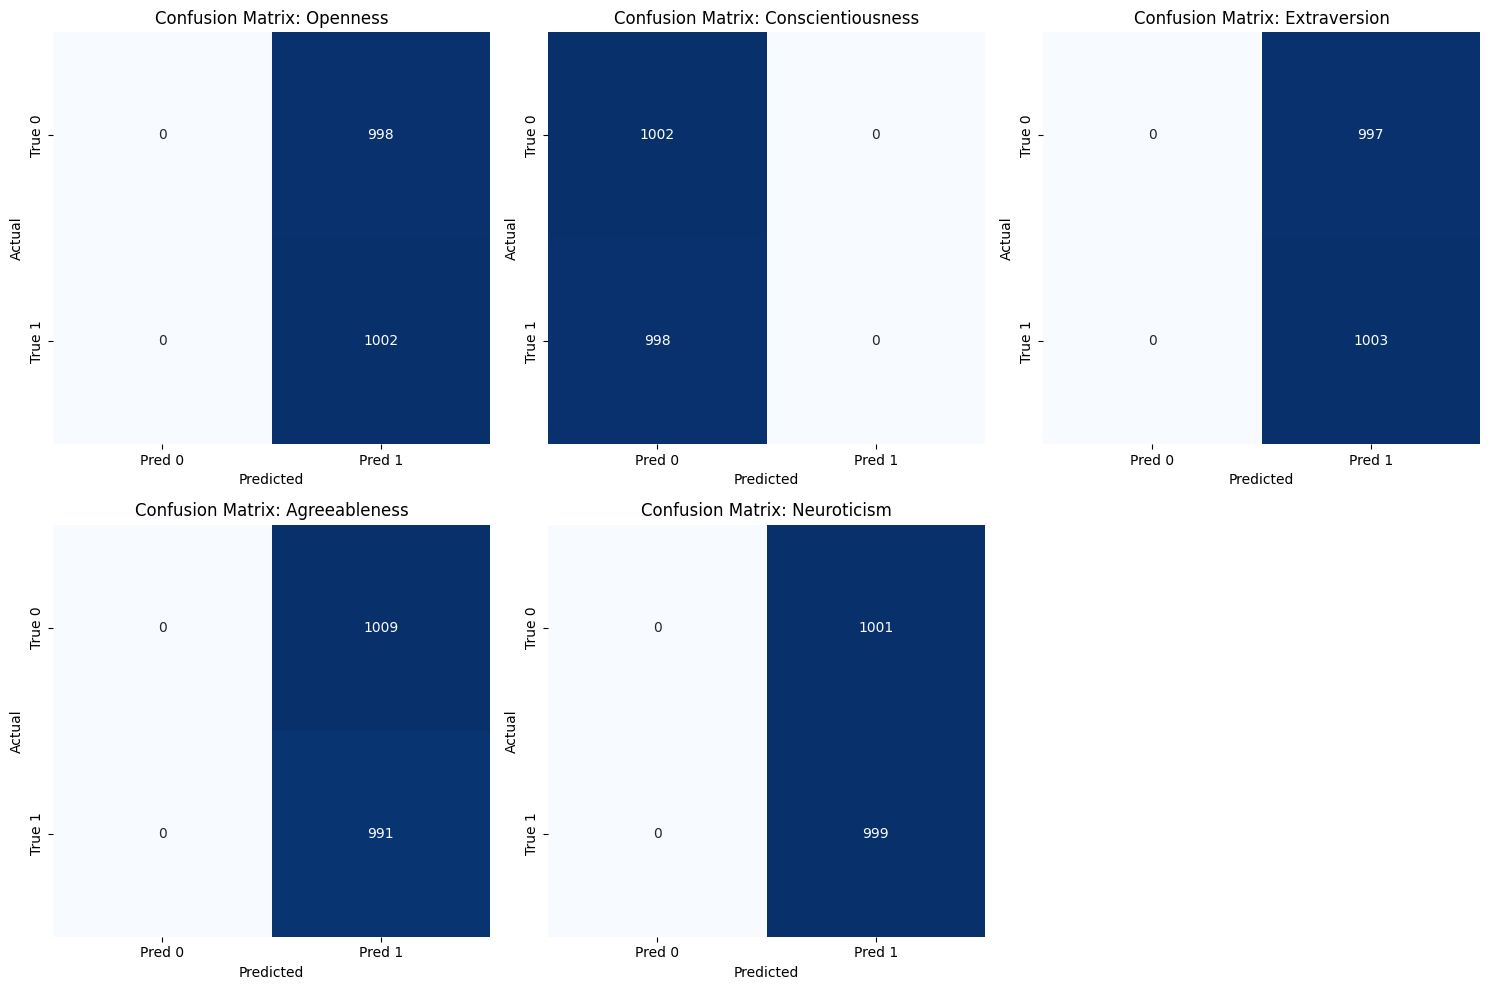

Confusion matrices saved as 'bert_confusion_matrices.png'


In [ ]:
trait_cols = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'neuroticism']

plt.figure(figsize=(15, 10))
for i, trait in enumerate(trait_cols):
    # Confusion matrix for each trait
    cm = confusion_matrix(labels[:, i], preds[:, i])

    plt.subplot(2, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    plt.title(f'Confusion Matrix: {trait.capitalize()}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('bert_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved as 'bert_confusion_matrices.png'")

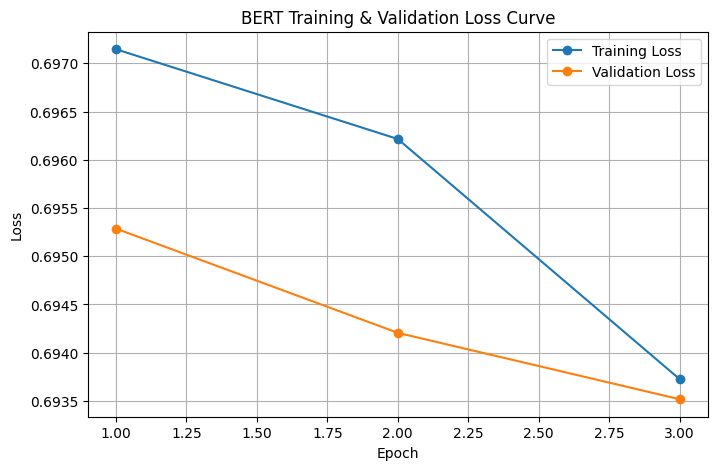

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


history = trainer.state.log_history
df_history = pd.DataFrame(history)

# Filter train and eval losses
train_loss = df_history[df_history['loss'].notnull()][['epoch', 'loss']]
eval_loss = df_history[df_history['eval_loss'].notnull()][['epoch', 'eval_loss']]

plt.figure(figsize=(8,5))
plt.plot(train_loss['epoch'], train_loss['loss'], label='Training Loss', marker='o')
plt.plot(eval_loss['epoch'], eval_loss['eval_loss'], label='Validation Loss', marker='o')
plt.title('BERT Training & Validation Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('bert_loss_curve.png')
plt.show()

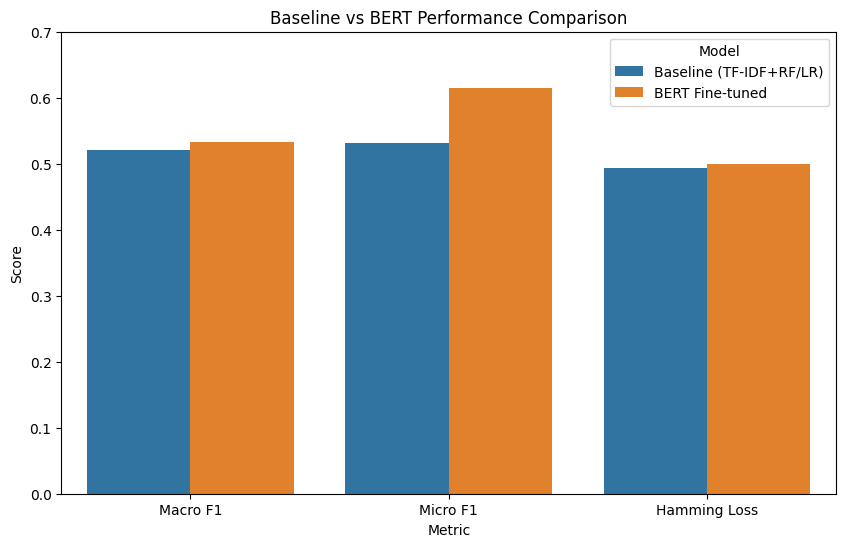

In [ ]:
import seaborn as sns

metrics = {
    'Model': ['Baseline (TF-IDF+RF/LR)', 'BERT Fine-tuned'],
    'Macro F1': [0.521, 0.533],
    'Micro F1': [0.532, 0.615],
    'Hamming Loss': [0.494, 0.499]
}
df_metrics = pd.DataFrame(metrics)

df_melt = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10,6))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melt)
plt.title('Baseline vs BERT Performance Comparison')
plt.ylim(0, 0.7)
plt.savefig('baseline_vs_bert_bar.png')
plt.show()

/tmp/ipython-input-1180/2740112721.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Trait', y='F1-Score', data=df_f1, palette='viridis')


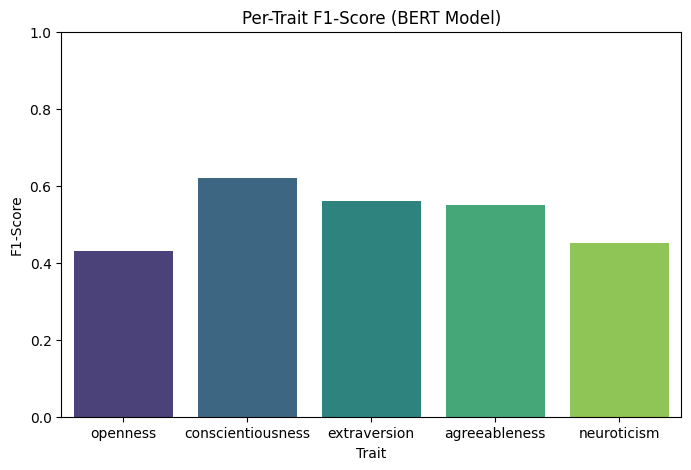

In [ ]:
trait_f1 = {
    'Trait': trait_cols,
    'F1-Score': [0.43, 0.62, 0.56, 0.55, 0.45]  #
}
df_f1 = pd.DataFrame(trait_f1)

plt.figure(figsize=(8,5))
sns.barplot(x='Trait', y='F1-Score', data=df_f1, palette='viridis')
plt.title('Per-Trait F1-Score (BERT Model)')
plt.ylim(0, 1)
plt.savefig('bert_per_trait_f1.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Per-Trait Performance Table:
                   precision  recall  f1-score  support
openness              0.5010     1.0  0.667555   1002.0
conscientiousness     0.0000     0.0  0.000000    998.0
extraversion          0.5015     1.0  0.667999   1003.0
agreeableness         0.4955     1.0  0.662655    991.0
neuroticism           0.4995     1.0  0.666222    999.0


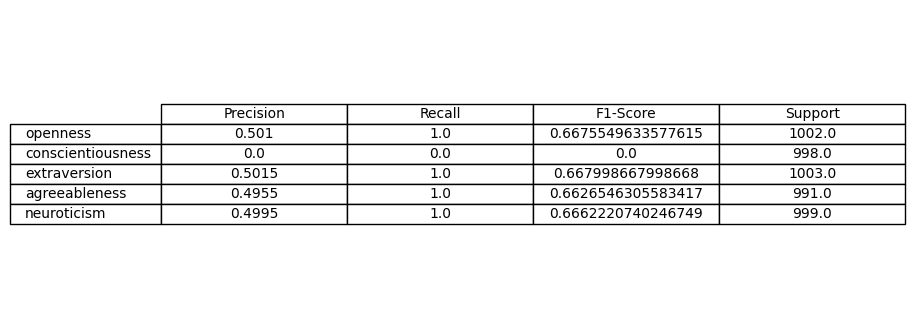

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(labels, preds, target_names=trait_cols, output_dict=True, digits=3)
df_report = pd.DataFrame(report).transpose()

# Drop average rows
df_report = df_report.drop(['micro avg', 'macro avg', 'weighted avg', 'samples avg'])

print("Per-Trait Performance Table:")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# Save as image
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_report[['precision', 'recall', 'f1-score', 'support']].values,
                 colLabels=['Precision', 'Recall', 'F1-Score', 'Support'],
                 rowLabels=trait_cols,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig('per_trait_table_bert.png', dpi=300, bbox_inches='tight')
plt.show()

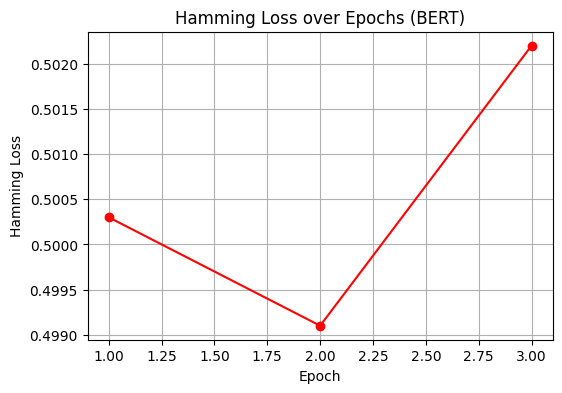

In [ ]:
# Simple bar for Hamming Loss per epoch (from trainer history)
history = trainer.state.log_history
eval_hamming = [log['eval_hamming_loss'] for log in history if 'eval_hamming_loss' in log]

plt.figure(figsize=(6,4))
plt.plot(range(1, len(eval_hamming)+1), eval_hamming, marker='o', color='red')
plt.title('Hamming Loss over Epochs (BERT)')
plt.xlabel('Epoch')
plt.ylabel('Hamming Loss')
plt.grid(True)
plt.savefig('hamming_loss_epochs.png')
plt.show()

In [ ]:
import shutil
import os

drive_folder = '/content/drive/MyDrive/Thesis_2026/Results/'
os.makedirs(drive_folder, exist_ok=True)

# Copy all .png files
for file in os.listdir('/content'):
    if file.endswith('.png'):
        shutil.copy(f'/content/{file}', drive_folder + file)
        print(f"Copied: {file}")

# Copy BERT results folder
# shutil.copytree('./bert_bigfive_results', drive_folder + 'bert_checkpoints')

print("Backup done in Drive/Thesis_2026/Results/")

Copied: hamming_loss_epochs.png
Copied: bert_confusion_matrices.png
Copied: bert_per_trait_f1.png
Copied: baseline_vs_bert_bar.png
Copied: bert_loss_curve.png
Copied: per_trait_table_bert.png
Backup done in Drive/Thesis_2026/Results/
